# 데이터 분석의 5단계 흐름

데이터 이해(EDA) -> 데이터 전처리 -> 모델링(학습) -> 성능 평가 -> 결과 해석

EDA는 단순히 그래프를 무작정 적는 단계가 아님
전처리 방식과 평가 지표를 결정하기 위한 사전 판단 단계

# 단위 차이가 왜곡을 만든다 (Scale)

변수마다 측정 단위가 다르면, 절대 값이 큰 변수가 모델의 판단을 지배한다.

StandardScaler / MinMaxScaler 사용하여 단위 맞춰주기

# 평가 지표 선택: 정확도(accuracy)의 함정에 빠지지 말것

질병 예측의 경우는 전체를 얼마나 잘 맞추었는가(accuracy) 보다
실제 환자를 얼마나 놓치지 않았는가(Recall)가 압도적으로 중요합니다.

# 기준모델 이 성능이 좋은가의 시작점

LogisticRegression
복잡한 머신러닝(RandomForestClassifier etc)을 적용하기 전, 
가장 기본적이고 해석이 쉬운 선형모델을 먼저 학습시킨다.

좋은 모델이란 기준이 없으니 비교를 통해 정의해야함

# 어떤 모델로 심장 질환을 예측할 것인가
- KNN
    - 거리기반(가장 유사한 환자 찾기)
    - 직관적이고 원리 이해가 쉬움
    - 스케일링(Scale)에 극도로 민감함
- DecisionTreeClassifier
    - 규칙기반(조건부 스무고개 질문 분기)
    - 설명력이 뛰어나며 의료적 rule 도출 가능
    - 트리가 깊어지면 학습 데이터에만 맞는 과적합 위험이 큼
- RandomForestClassifier
    - 앙상블 (majorty vote)
    - 과적합을 방지하며, 가장 안정적이며 고성능 발휘
    - 내부 연산이 복잡해 단일 트리만큼 완벽한 해석은 어려움

# 하이퍼파라미터 튜닝
- 복잡함이 아닌 최적화 과정
- GridSeaerchCV, RandomizedSearchCV

# Feature Inportance: 주장을 뒷받침하는 결정적 증거
- 그래프는 그 자체로 결론이 아니라, 여러분의 논리적 주장을 시각적으로 입증하는 증거자료입니다.

In [1]:
# 1. 라이브러리 불러오기
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score, recall_score, precision_score, f1_score,
    confusion_matrix, classification_report, mean_squared_error
)

In [4]:
df = pd.read_csv("heart.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [7]:
print(df.shape)
print('-'*30)
df.info()
print('-'*30)
display(df.describe())

(1025, 14)
------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB
------------------------------


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [8]:
# 4. 컬럼명 및 타깃 분포
print(df.columns.tolist())
print()
print(df["target"].value_counts())
print()
print(df["target"].value_counts(normalize=True))

['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

target
1    526
0    499
Name: count, dtype: int64

target
1    0.513171
0    0.486829
Name: proportion, dtype: float64


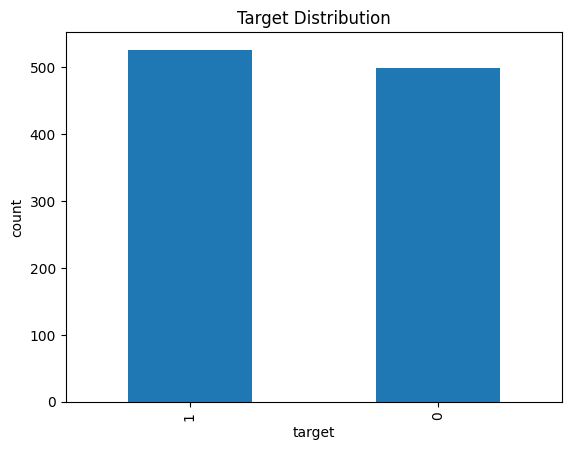

In [9]:
# 5. 타깃 분포 시각화
df["target"].value_counts().plot(kind="bar")
plt.title("Target Distribution")
plt.xlabel("target")
plt.ylabel("count")
plt.show()

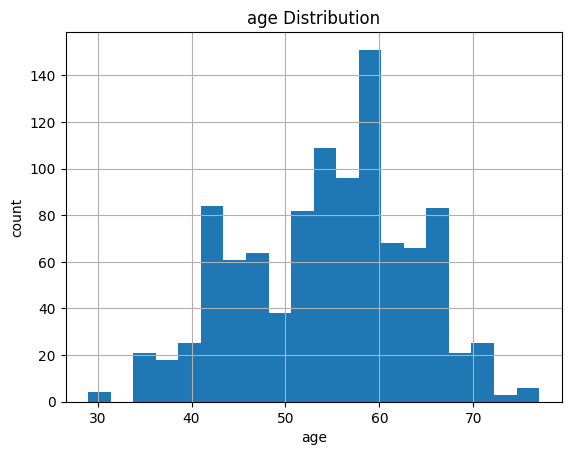

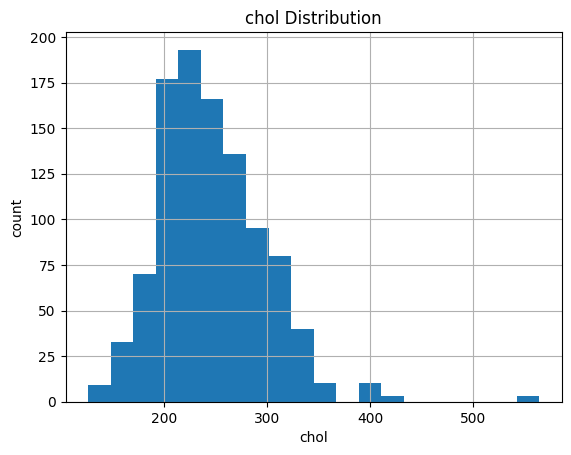

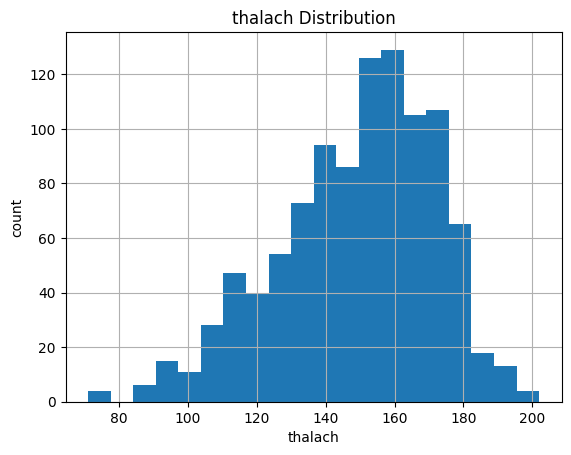

In [10]:
# 6. 주요 변수 히스토그램
num_cols = ["age", "chol", "thalach"]

for col in num_cols:
    df[col].hist(bins=20)
    plt.title(f"{col} Distribution")
    plt.xlabel(col)
    plt.ylabel("count")
    plt.show()

In [11]:
# 7. 타깃별 평균 비교
group_means = df.groupby("target")[["age", "chol", "thalach"]].mean()
group_means

,age,chol,thalach
target,,,
0,56.569138,251.292585,139.130261
1,52.408745,240.979087,158.585551


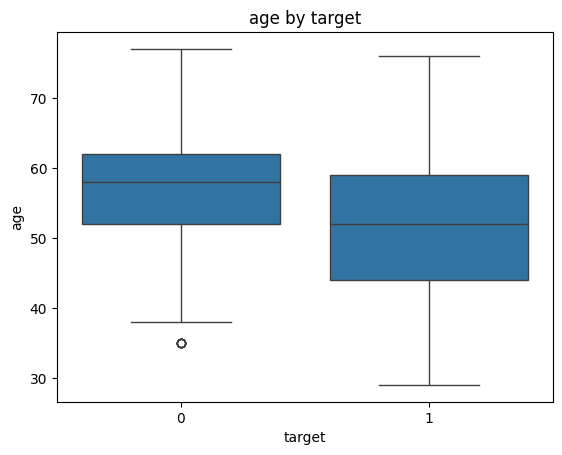

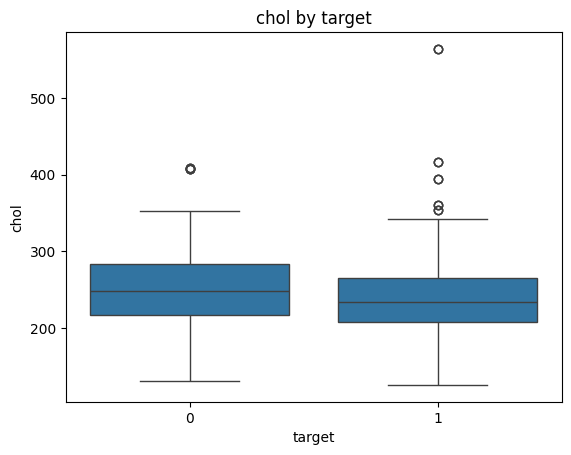

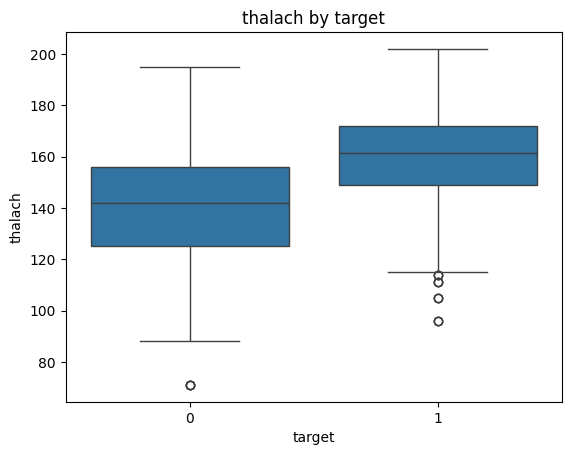

In [12]:
# 8. boxplot으로 분포 비교
for col in ["age", "chol", "thalach"]:
    sns.boxplot(data=df, x="target", y=col)
    plt.title(f"{col} by target")
    plt.show()

In [13]:
# 9. x, y 분리
x = df.drop("target", axis=1)
y = df["target"]

print("x shape:", x.shape)
print("y shape:", y.shape)

x shape: (1025, 13)
y shape: (1025,)


In [14]:
# 10. train/test split
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.3, random_state=42, stratify=y
)

print("x_train:", x_train.shape)
print("x_test :", x_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

x_train: (717, 13)
x_test : (308, 13)
y_train: (717,)
y_test : (308,)


In [15]:
# 11. 기준 모델 학습
pipe_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

pipe_lr.fit(x_train, y_train)
y_pred_lr = pipe_lr.predict(x_test)


In [ ]:

# 12. 기준 모델 성능 평가
acc_lr = accuracy_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)

print("Accuracy :", round(acc_lr, 4))
print("Recall   :", round(recall_lr, 4))
print("Precision:", round(precision_lr, 4))
print("F1-score :", round(f1_lr, 4))
print()
print(classification_report(y_test, y_pred_lr))
